# **AL-VOTE Civic Participation Analysis**

**SETUP**

In [ ]:
library(tidyverse)
library(scales)

options(
  repr.plot.width = 10,
  repr.plot.height = 6
)

In [ ]:
age <- read_csv(
  "age_participation_clean.csv",
  show_col_types = FALSE
)

cvap <- read_csv(
  "cvap_clean.csv",
  show_col_types = FALSE
)

contest <- read_csv(
  "election_contest_summary_clean.csv",
  show_col_types = FALSE
)

results <- read_csv(
  "election_results_clean.csv",
  show_col_types = FALSE
)

gender <- read_csv(
  "gender_participation_clean.csv",
  show_col_types = FALSE
)

race <- read_csv(
  "race_participation_clean.csv",
  show_col_types = FALSE
)

registration <- read_csv(
  "voter_registration_clean.csv",
  show_col_types = FALSE
)

In [ ]:
priority_counties <- c(
  "Talladega",
  "Tuscaloosa",
  "Etowah",
  "Calhoun",
  "Chambers",
  "Madison",
  "Jefferson",
  "Shelby"
)

priority_counties

[1] "Talladega"  "Tuscaloosa" "Etowah"     "Calhoun"    "Chambers"  
[6] "Madison"    "Jefferson"  "Shelby"

**VIS FORMAT**

In [ ]:
project_theme <- theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(
      size = 16,
      face = "bold"
    ),
    plot.subtitle = element_text(
      size = 11
    ),
    axis.title = element_text(
      size = 11
    ),
    legend.position = "bottom",
    panel.grid.minor = element_blank()
  )


**OVERALL VOTER PARTICIPATION**

In [ ]:
overall_turnout <- gender %>%
  select(
    year,
    county_name,
    total_participants
  ) %>%
  left_join(
    cvap %>%
      select(
        year,
        county_name,
        cvap_est_total
      ),
    by = c("year", "county_name")
  ) %>%
  mutate(
    participation_rate =
      (total_participants / cvap_est_total) * 100
  )

head(overall_turnout)

year,county_name,total_participants,cvap_est_total,participation_rate
<dbl>,<chr>,<dbl>,<dbl>,<dbl>
2020,Autauga,27681,41960,65.96997
2024,Autauga,28401,45205,62.82712
2020,Bibb,8797,17585,50.02559
2024,Bibb,9283,17349,53.50741
2020,Blount,27694,42980,64.43462
2024,Blount,28255,43938,64.30652


In [ ]:
overall_turnout %>%
  group_by(year) %>%
  summarise(
    average_rate = mean(participation_rate, na.rm = TRUE),
    median_rate = median(participation_rate, na.rm = TRUE),
    minimum_rate = min(participation_rate, na.rm = TRUE),
    maximum_rate = max(participation_rate, na.rm = TRUE)
  )

year,average_rate,median_rate,minimum_rate,maximum_rate
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2020,62.00873,61.45874,50.02559,71.66344
2024,59.46602,60.31524,46.78331,67.10938


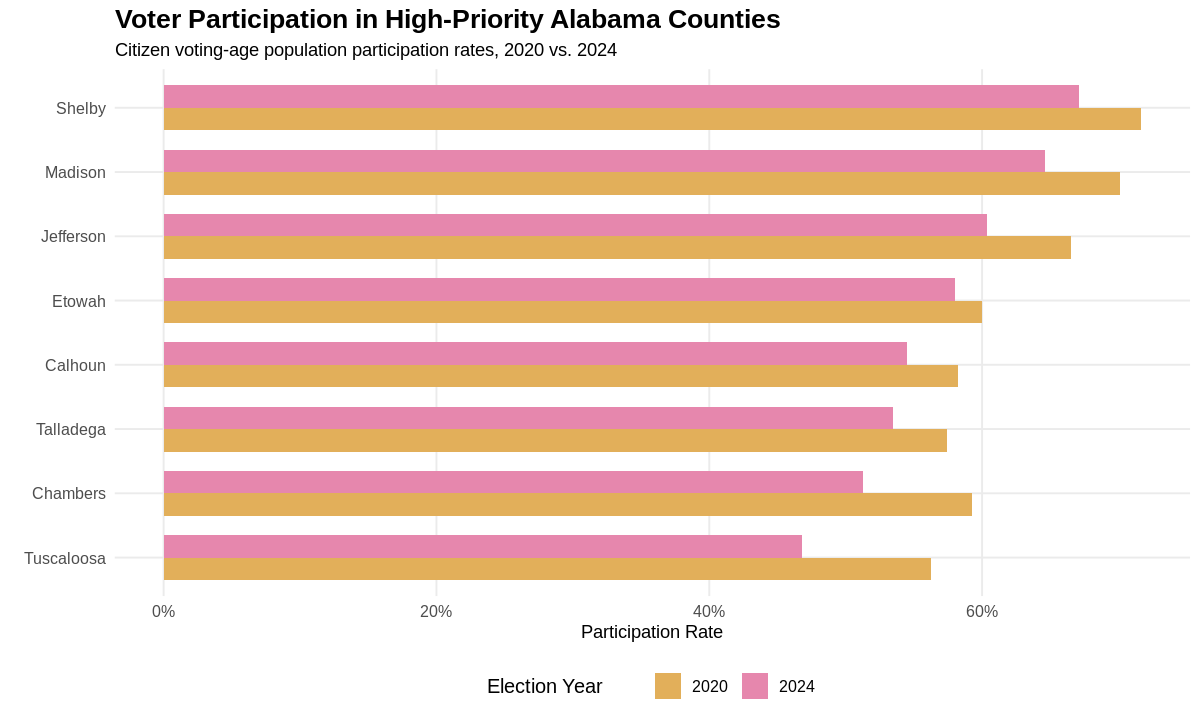

In [ ]:
overall_turnout %>%
  filter(county_name %in% priority_counties) %>%
  ggplot(
    aes(
      x = reorder(county_name, participation_rate),
      y = participation_rate,
      fill = factor(year)
    )
  ) +
  geom_col(
    position = "dodge",
    width = 0.7
  ) +
  coord_flip() +
  scale_y_continuous(
    labels = label_percent(scale = 1)
  ) +
  scale_fill_manual(
    values = c(
      "2020" = "#E2AF5A",
      "2024" = "#E687AD"
    )
  ) +
  labs(
    title = "Voter Participation in High-Priority Alabama Counties",
    subtitle = "Citizen voting-age population participation rates, 2020 vs. 2024",
    x = NULL,
    y = "Participation Rate",
    fill = "Election Year"
  ) +
  project_theme

*Overall voter participation declined from 2020 to 2024 across all eight high-priority counties. In 2020, Shelby County had the highest participation rate at approximately 71.7%, followed by Madison County at 70.1% and Jefferson County at 66.5%. Tuscaloosa County had the lowest rate at approximately 56.2%. By 2024, participation was lower across all eight counties, although Shelby and Madison continued to have the highest rates. These differences suggest that both participation levels and the degree of decline varied meaningfully across counties.*

**2020 VS 2024**

In [ ]:
turnout_change <- overall_turnout %>%
  select(
    year,
    county_name,
    participation_rate
  ) %>%
  pivot_wider(
    names_from = year,
    values_from = participation_rate,
    names_prefix = "rate_"
  ) %>%
  mutate(
    change_2020_2024 =
      rate_2024 - rate_2020
  )

head(turnout_change)

county_name,rate_2020,rate_2024,change_2020_2024
<chr>,<dbl>,<dbl>,<dbl>
Autauga,65.96997,62.82712,-3.1428505
Bibb,50.02559,53.50741,3.4818168
Blount,64.43462,64.30652,-0.1280979
Calhoun,58.22061,54.47899,-3.7416198
Chambers,59.28011,51.28714,-7.9929637
Cherokee,60.02903,61.41176,1.3827371


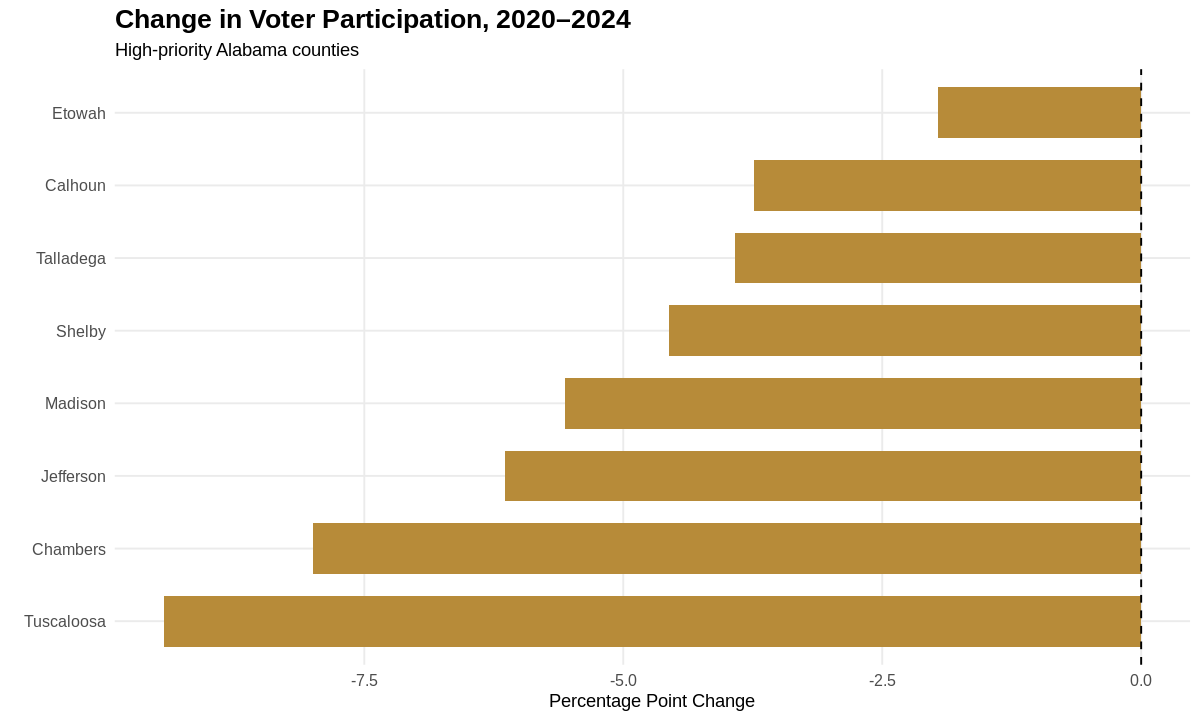

In [ ]:
turnout_change %>%
  filter(county_name %in% priority_counties) %>%
  ggplot(
    aes(
      x = reorder(county_name, change_2020_2024),
      y = change_2020_2024
    )
  ) +
  geom_col(
    width = 0.7,
    fill = "#B78B39"
  ) +
  geom_hline(
    yintercept = 0,
    linetype = "dashed"
  ) +
  coord_flip() +
  labs(
    title = "Change in Voter Participation, 2020–2024",
    subtitle = "High-priority Alabama counties",
    x = NULL,
    y = "Percentage Point Change"
  ) +
  project_theme

Above 0 = participation increased
Below 0 = participation decreased

*All eight high-priority counties experienced a decline in estimated voter participation between 2020 and 2024. The largest decrease occurred in Tuscaloosa County, where participation fell by approximately 9.4 percentage points, followed by Chambers County with an 8.0-point decline. Etowah County experienced the smallest decline at approximately 2.0 percentage points. This indicates that the decrease in participation was not uniform across the priority counties.*

**BLACK VOTER PARTICIPATION**

In [ ]:
black_participation <- race %>%
  select(
    year,
    county_name,
    total_black
  ) %>%
  left_join(
    cvap %>%
      select(
        year,
        county_name,
        cvap_est_black
      ),
    by = c("year", "county_name")
  ) %>%
  mutate(
    black_participation_rate =
      (total_black / cvap_est_black) * 100
  )

head(black_participation)

year,county_name,total_black,cvap_est_black,black_participation_rate
<dbl>,<chr>,<dbl>,<dbl>,<dbl>
2020,Autauga,5091,8135,62.58144
2024,Autauga,5114,9392,54.45060
2020,Bibb,1422,4000,35.55000
2024,Bibb,1239,3668,33.77863
2020,Blount,299,610,49.01639
2024,Blount,321,744,43.14516


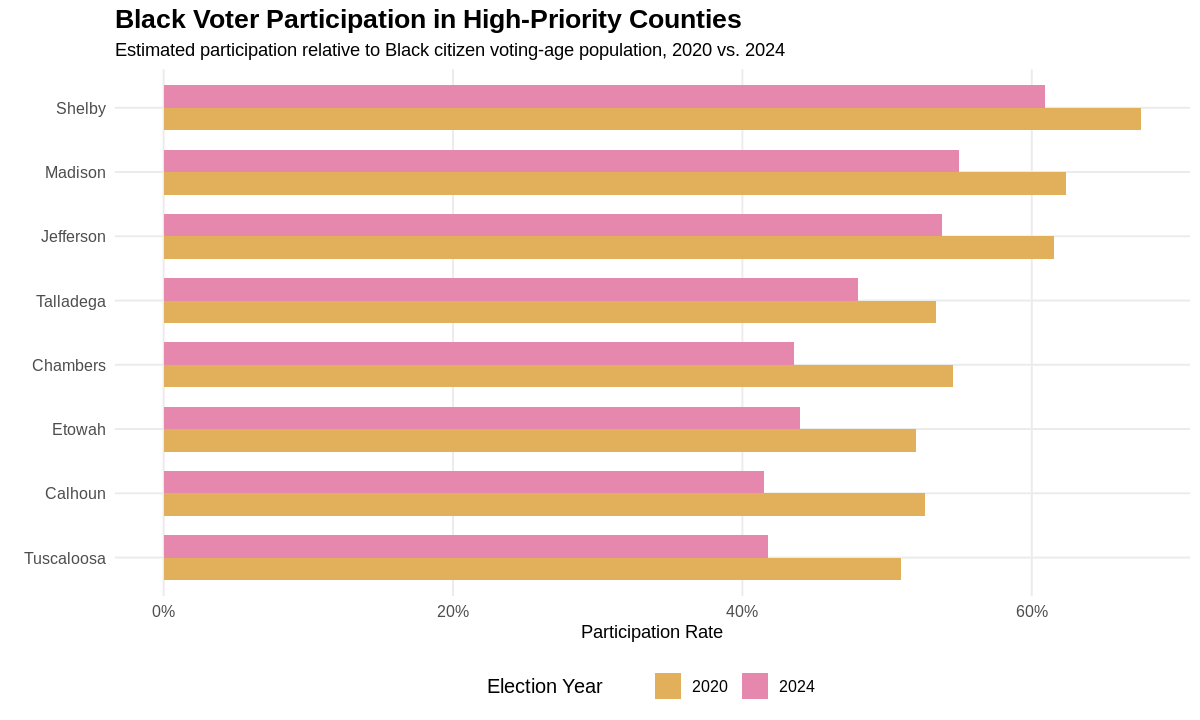

In [ ]:
black_participation %>%
  filter(
    county_name %in% priority_counties
  ) %>%
  ggplot(
    aes(
      x = reorder(county_name, black_participation_rate),
      y = black_participation_rate,
      fill = factor(year)
    )
  ) +
  geom_col(
    position = "dodge",
    width = 0.7
  ) +
  coord_flip() +
  scale_y_continuous(
    labels = label_percent(scale = 1)
  ) +
  scale_fill_manual(
    values = c(
      "2020" = "#E2AF5A",
      "2024" = "#E687AD"
    )
  ) +
  labs(
    title = "Black Voter Participation in High-Priority Counties",
    subtitle = "Estimated participation relative to Black citizen voting-age population, 2020 vs. 2024",
    x = NULL,
    y = "Participation Rate",
    fill = "Election Year"
  ) +
  project_theme

*Estimated Black voter participation declined from 2020 to 2024 in all eight high-priority counties. Shelby County had the highest Black participation rate in both years, decreasing from approximately 67.6% in 2020 to 60.9% in 2024. Madison County declined from 62.4% to 55.0%, while Jefferson County declined from 61.5% to 53.8%. Tuscaloosa experienced one of the largest decreases, falling from approximately 51.0% to 41.8%. Overall, the visualization shows both substantial county-level differences and a consistent decline in estimated Black participation between the two election years.*

**LATINX VOTER PARTICIPATION**

In [ ]:
hispanic_participation <- race %>%
  select(
    year,
    county_name,
    total_hispanic
  ) %>%
  left_join(
    cvap %>%
      select(
        year,
        county_name,
        cvap_est_hispanic
      ),
    by = c("year", "county_name")
  ) %>%
  mutate(
    hispanic_participation_rate =
      (total_hispanic / cvap_est_hispanic) * 100
  )

head(hispanic_participation)

year,county_name,total_hispanic,cvap_est_hispanic,hispanic_participation_rate
<dbl>,<chr>,<dbl>,<dbl>,<dbl>
2020,Autauga,189,840,22.50000
2024,Autauga,225,1199,18.76564
2020,Bibb,25,230,10.86957
2024,Bibb,35,199,17.58794
2020,Blount,475,2050,23.17073
2024,Blount,572,2218,25.78900


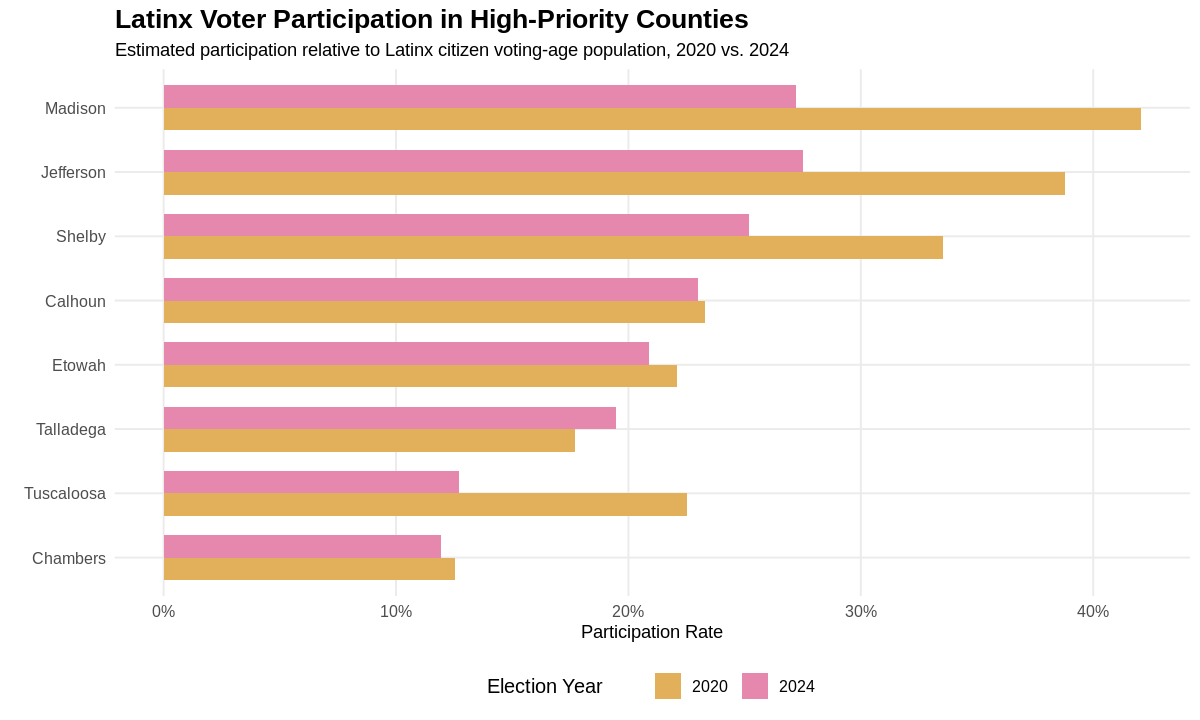

In [ ]:
hispanic_participation %>%
  filter(
    county_name %in% priority_counties
  ) %>%
  ggplot(
    aes(
      x = reorder(county_name, hispanic_participation_rate),
      y = hispanic_participation_rate,
      fill = factor(year)
    )
  ) +
  geom_col(
    position = "dodge",
    width = 0.7
  ) +
  coord_flip() +
  scale_y_continuous(
    labels = label_percent(scale = 1)
  ) +
  scale_fill_manual(
    values = c(
      "2020" = "#E2AF5A",
      "2024" = "#E687AD"
    )
  ) +
  labs(
    title = "Latinx Voter Participation in High-Priority Counties",
    subtitle = "Estimated participation relative to Latinx citizen voting-age population, 2020 vs. 2024",
    x = NULL,
    y = "Participation Rate",
    fill = "Election Year"
  ) +
  project_theme

*Latinx voter participation varied considerably across counties and generally declined between 2020 and 2024. Madison County had the highest estimated rate in 2020 at approximately 42.1%, but this fell substantially to 27.2% in 2024. Jefferson County similarly declined from 38.8% to 27.5%, while Shelby County decreased from 33.5% to 25.2%. Chambers County remained among the lowest in both years, at approximately 12.5% in 2020 and 11.9% in 2024. Talladega was one exception to the overall decline, increasing slightly from approximately 17.7% to 19.5%.*

**RACIAL PARTICIPATION GAP**

In [ ]:
race_rates <- race %>%
  select(
    year,
    county_name,
    total_black,
    total_white,
    total_hispanic
  ) %>%
  left_join(
    cvap %>%
      select(
        year,
        county_name,
        cvap_est_black,
        cvap_est_white,
        cvap_est_hispanic
      ),
    by = c("year", "county_name")
  ) %>%
  mutate(
    black_rate =
      (total_black / cvap_est_black) * 100,

    white_rate =
      (total_white / cvap_est_white) * 100,

    hispanic_rate =
      (total_hispanic / cvap_est_hispanic) * 100,

    black_white_gap =
      black_rate - white_rate
  )

head(race_rates)

year,county_name,total_black,total_white,total_hispanic,cvap_est_black,cvap_est_white,cvap_est_hispanic,black_rate,white_rate,hispanic_rate,black_white_gap
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2020,Autauga,5091,21885,189,8135,31990,840,62.58144,68.41200,22.50000,-5.830566
2024,Autauga,5114,22571,225,9392,33452,1199,54.45060,67.47280,18.76564,-13.022201
2020,Bibb,1422,7300,25,4000,13220,230,35.55000,55.21936,10.86957,-19.669365
2024,Bibb,1239,7947,35,3668,13105,199,33.77863,60.64098,17.58794,-26.862351
2020,Blount,299,26645,475,610,39595,2050,49.01639,67.29385,23.17073,-18.277457
2024,Blount,321,27068,572,744,40154,2218,43.14516,67.41047,25.78900,-24.265308


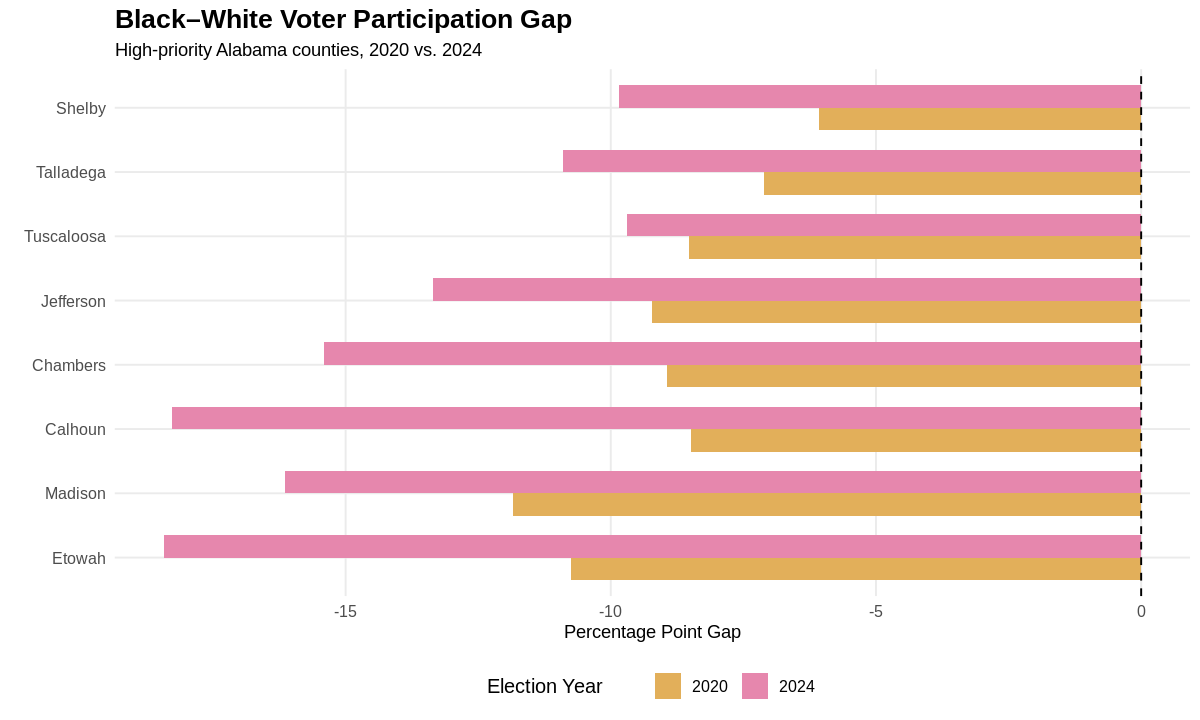

In [ ]:
race_rates %>%
  filter(
    county_name %in% priority_counties
  ) %>%
  ggplot(
    aes(
      x = reorder(county_name, black_white_gap),
      y = black_white_gap,
      fill = factor(year)
    )
  ) +
  geom_col(
    position = "dodge",
    width = 0.7
  ) +
  geom_hline(
    yintercept = 0,
    linetype = "dashed"
  ) +
  coord_flip() +
  scale_fill_manual(
    values = c(
      "2020" = "#E2AF5A",
      "2024" = "#E687AD"
    )
  ) +
  labs(
    title = "Black–White Voter Participation Gap",
    subtitle = "High-priority Alabama counties, 2020 vs. 2024",
    x = NULL,
    y = "Percentage Point Gap",
    fill = "Election Year"
  ) +
  project_theme

Negative gap = Black participation lower than White participation
Positive gap = Black participation higher than White participation

*Black participation rates were lower than White participation rates in every high-priority county in both 2020 and 2024, as shown by the consistently negative values. More importantly, the racial participation gap widened in every county between the two elections. In Calhoun County, for example, the gap increased from approximately 8.5 percentage points in 2020 to 18.3 points in 2024. Etowah similarly widened from about 10.8 to 18.4 points, while Madison increased from approximately 11.8 to 16.1 points. Shelby County had the smallest gap in both years, although it still increased from approximately 6.1 to 9.8 percentage points.*

**VOTER REGISTRATION VS PARTICIPATION**

In [ ]:
registration_participation <- gender %>%
  select(
    year,
    county_name,
    total_participants
  ) %>%
  left_join(
    registration %>%
      select(
        year,
        county_name,
        registered_total
      ),
    by = c("year", "county_name")
  ) %>%
  mutate(
    registered_voter_participation_rate =
      (total_participants / registered_total) * 100
  )

head(registration_participation)

year,county_name,total_participants,registered_total,registered_voter_participation_rate
<dbl>,<chr>,<dbl>,<dbl>,<dbl>
2020,Autauga,27681,43482,63.66083
2024,Autauga,28401,46518,61.05379
2020,Bibb,8797,14992,58.67796
2024,Bibb,9283,15161,61.22947
2020,Blount,27694,41865,66.15072
2024,Blount,28255,43611,64.78870


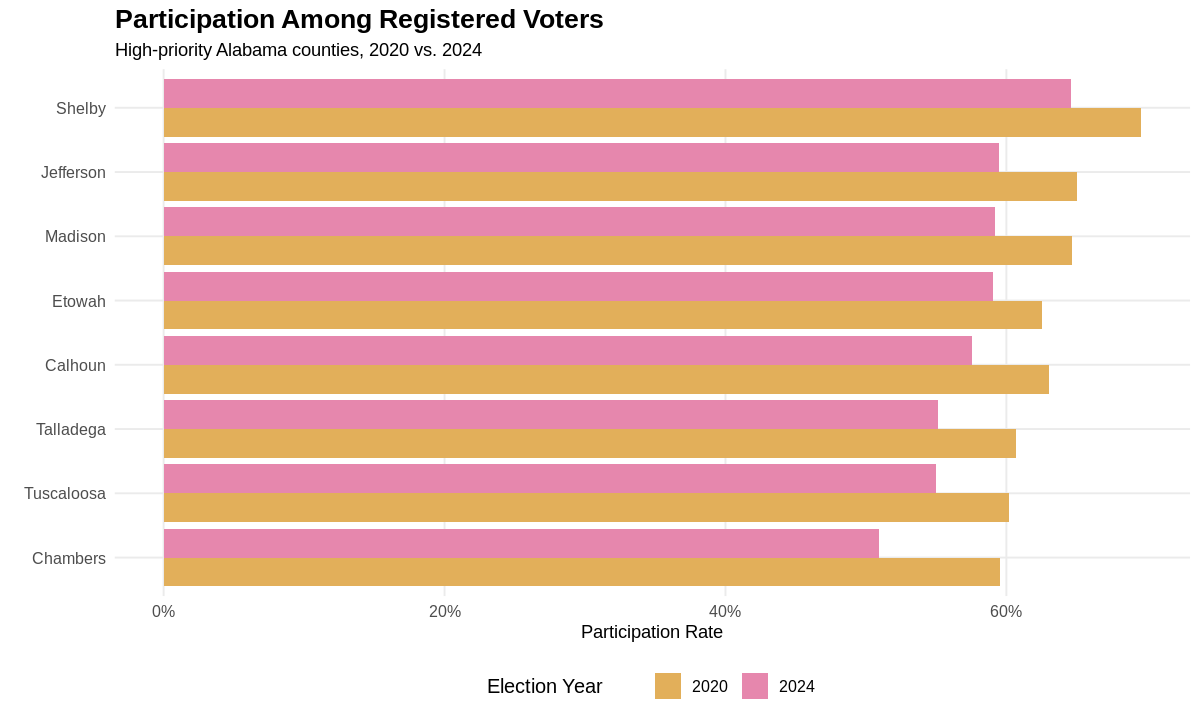

In [ ]:
registration_participation %>%
  filter(county_name %in% priority_counties) %>%
  ggplot(
    aes(
      x = reorder(
        county_name,
        registered_voter_participation_rate
      ),
      y = registered_voter_participation_rate,
      fill = factor(year)
    )
  ) +
  geom_col(
    position = "dodge"
  ) +
  coord_flip() +
  scale_y_continuous(
    labels = label_percent(scale = 1)
  ) +
  scale_fill_manual(
    values = c(
      "2020" = "#E2AF5A",
      "2024" = "#E687AD"
    )
  ) +
  labs(
    title = "Participation Among Registered Voters",
    subtitle = "High-priority Alabama counties, 2020 vs. 2024",
    x = NULL,
    y = "Participation Rate",
    fill = "Election Year"
  ) +
  project_theme

*Participation among registered voters declined between 2020 and 2024 across all eight priority counties. In 2020, Shelby County had the highest rate at approximately 69.6%, while Chambers County had the lowest at approximately 59.6%. By 2024, Shelby remained the highest at approximately 64.6%, while Chambers declined to approximately 50.9%. This suggests that differences in participation cannot be understood solely through registration totals, since a substantial share of registered voters did not participate.*

**AGE DISTRIBUTION OF VOTERS**

In [ ]:
age_long <- age %>%
  pivot_longer(
    cols = starts_with("age_"),
    names_to = "age_group",
    values_to = "participants"
  ) %>%
  mutate(
    age_group = recode(
      age_group,
      "age_18_29" = "18–29",
      "age_30_39" = "30–39",
      "age_40_49" = "40–49",
      "age_50_59" = "50–59",
      "age_60_69" = "60–69",
      "age_70_79" = "70–79",
      "age_80_89" = "80–89",
      "age_90_99" = "90–99",
      "age_100_plus" = "100+"
    ),
    participation_share =
      (participants / total_participants) * 100
  )

head(age_long)

year,county_name,total_participants,age_group,participants,participation_share
<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
2020,Autauga,27681,18–29,3701,13.37018
2020,Autauga,27681,30–39,4051,14.63459
2020,Autauga,27681,40–49,4619,16.68654
2020,Autauga,27681,50–59,5512,19.91258
2020,Autauga,27681,60–69,5047,18.23272
2020,Autauga,27681,70–79,3277,11.83845


In [ ]:
priority_age_summary <- age_long %>%
  filter(
    county_name %in% priority_counties
  ) %>%
  group_by(
    year,
    age_group
  ) %>%
  summarise(
    participants = sum(participants, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(year) %>%
  mutate(
    participation_share =
      participants / sum(participants) * 100
  ) %>%
  ungroup()

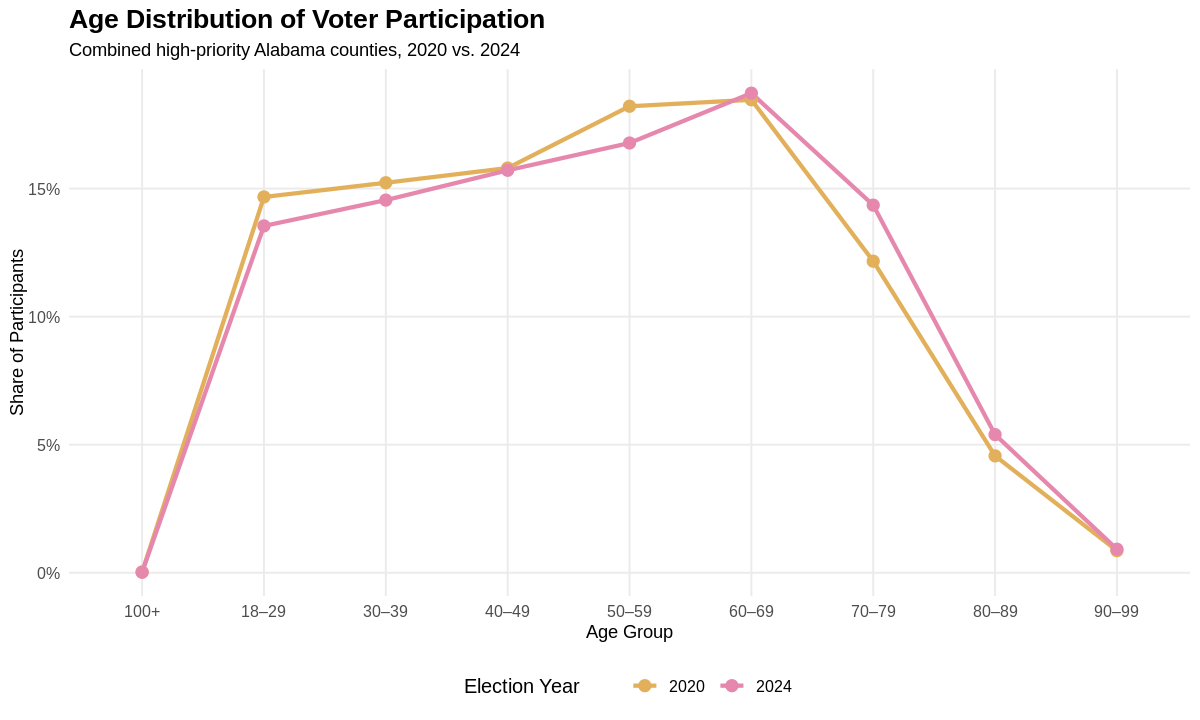

In [ ]:
priority_age_summary %>%
  ggplot(
    aes(
      x = age_group,
      y = participation_share,
      group = factor(year),
      color = factor(year)
    )
  ) +
  geom_line(
    linewidth = 1.2
  ) +
  geom_point(
    size = 3
  ) +
  scale_y_continuous(
    labels = label_percent(scale = 1)
  ) +
  scale_color_manual(
    values = c(
      "2020" = "#E2AF5A",
      "2024" = "#E687AD"
    )
  ) +
  labs(
    title = "Age Distribution of Voter Participation",
    subtitle = "Combined high-priority Alabama counties, 2020 vs. 2024",
    x = "Age Group",
    y = "Share of Participants",
    color = "Election Year"
  ) +
  project_theme

shows the age composition of people who participated not an age-specific turnout rate

*Voter participation in the priority counties was concentrated primarily among middle-aged and older adults in 2020. Across the eight counties combined, voters ages 60–69 represented approximately 18.5% of participants, while those ages 50–59 represented about 18.2%. By comparison, voters ages 18–29 accounted for approximately 14.7%. Participation shares declined substantially among the oldest age groups, particularly after age 80. Although the exact distribution varied by county, the counties generally followed a similar age pattern.*

*The age distribution of voters remained broadly similar between 2020 and 2024, with participation concentrated among middle-aged and older voters. In 2020, voters ages 60–69 represented approximately 18.5% of participants across the eight priority counties, while ages 50–59 represented about 18.2%. Younger voters ages 18–29 represented approximately 14.7%. By 2024, the share represented by ages 18–29 declined to approximately 13.5%, while participation among older age groups became slightly more prominent. Overall, the distribution suggests a modest shift toward an older participant population between the two elections.*

**GENDER PARTICIPATION**

In [ ]:
gender_long <- gender %>%
  select(
    year,
    county_name,
    total_participants,
    female_votes,
    male_votes
  ) %>%
  pivot_longer(
    cols = c(
      female_votes,
      male_votes
    ),
    names_to = "gender",
    values_to = "participants"
  ) %>%
  mutate(
    gender = recode(
      gender,
      "female_votes" = "Female",
      "male_votes" = "Male"
    ),
    participation_share =
      (participants / total_participants) * 100
  )

head(gender_long)

year,county_name,total_participants,gender,participants,participation_share
<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
2020,Autauga,27681,Female,15245,55.07388
2020,Autauga,27681,Male,12310,44.47094
2024,Autauga,28401,Female,15750,55.45579
2024,Autauga,28401,Male,12581,44.29774
2020,Bibb,8797,Female,4801,54.57542
2020,Bibb,8797,Male,3989,45.34500


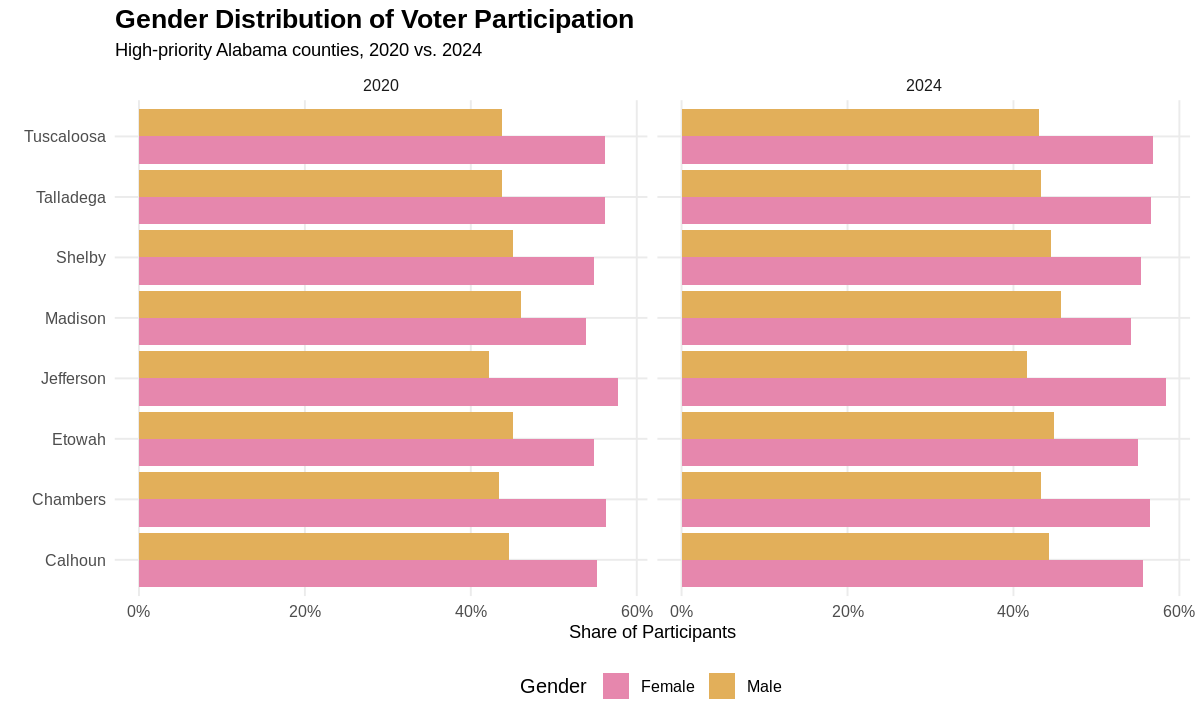

In [ ]:
gender_long %>%
  filter(
    county_name %in% priority_counties
  ) %>%
  ggplot(
    aes(
      x = county_name,
      y = participation_share,
      fill = gender
    )
  ) +
  geom_col(
    position = "dodge"
  ) +
  coord_flip() +
  facet_wrap(
    ~ year
  ) +
  scale_y_continuous(
    labels = label_percent(scale = 1)
  ) +
  scale_fill_manual(
    values = c(
      "Female" = "#E687AD",
      "Male" = "#E2AF5A"
    )
  ) +
  labs(
    title = "Gender Distribution of Voter Participation",
    subtitle = "High-priority Alabama counties, 2020 vs. 2024",
    x = NULL,
    y = "Share of Participants",
    fill = "Gender"
  ) +
  project_theme

*Female voters represented a larger share of participants than male voters in every high-priority county in both election years. In 2020, the female share ranged from approximately 53.8% in Madison County to 57.8% in Jefferson County. The same pattern continued in 2024, with women representing approximately 54.1% in Madison County and 58.4% in Jefferson County. Changes between the two years were relatively small compared with the differences observed in the race and overall participation analyses, indicating that the gender composition of participants remained fairly stable.*

**Black & Latinx: Registration vs. Participation**

In [ ]:
race_registration_analysis <- race %>%
  select(
    year,
    county_name,
    total_black,
    total_hispanic
  ) %>%
  left_join(
    registration %>%
      select(
        year,
        county_name,
        active_black,
        active_hispanic
      ),
    by = c("year", "county_name")
  ) %>%
  left_join(
    cvap %>%
      select(
        year,
        county_name,
        cvap_est_black,
        cvap_est_hispanic
      ),
    by = c("year", "county_name")
  ) %>%
  mutate(
    black_registration_rate =
      active_black / cvap_est_black * 100,

    black_participation_rate =
      total_black / cvap_est_black * 100,

    black_registered_turnout =
      total_black / active_black * 100,

    hispanic_registration_rate =
      active_hispanic / cvap_est_hispanic * 100,

    hispanic_participation_rate =
      total_hispanic / cvap_est_hispanic * 100,

    hispanic_registered_turnout =
      total_hispanic / active_hispanic * 100
  )

head(race_registration_analysis)

year,county_name,total_black,total_hispanic,active_black,active_hispanic,cvap_est_black,cvap_est_hispanic,black_registration_rate,black_participation_rate,black_registered_turnout,hispanic_registration_rate,hispanic_participation_rate,hispanic_registered_turnout
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2020,Autauga,5091,189,7992,329,8135,840,98.24216,62.58144,63.70120,39.16667,22.50000,57.44681
2024,Autauga,5114,225,8588,443,9392,1199,91.43952,54.45060,59.54821,36.94746,18.76564,50.79007
2020,Bibb,1422,25,2575,55,4000,230,64.37500,35.55000,55.22330,23.91304,10.86957,45.45455
2024,Bibb,1239,35,2507,77,3668,199,68.34787,33.77863,49.42162,38.69347,17.58794,45.45455
2020,Blount,299,475,603,1083,610,2050,98.85246,49.01639,49.58541,52.82927,23.17073,43.85965
2024,Blount,321,572,712,1491,744,2218,95.69892,43.14516,45.08427,67.22272,25.78900,38.36351


In [ ]:
registration_vs_participation <- race_registration_analysis %>%
  select(
    year,
    county_name,
    black_registration_rate,
    black_participation_rate,
    hispanic_registration_rate,
    hispanic_participation_rate
  ) %>%
  pivot_longer(
    cols = -c(year, county_name),
    names_to = "measure",
    values_to = "rate"
  ) %>%
  mutate(
    race_group = if_else(
      str_detect(measure, "black"),
      "Black",
      "Latinx"
    ),

    stage = if_else(
      str_detect(measure, "registration"),
      "Registered",
      "Participated"
    )
  )

head(registration_vs_participation)

year,county_name,measure,rate,race_group,stage
<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
2020,Autauga,black_registration_rate,98.24216,Black,Registered
2020,Autauga,black_participation_rate,62.58144,Black,Participated
2020,Autauga,hispanic_registration_rate,39.16667,Latinx,Registered
2020,Autauga,hispanic_participation_rate,22.50000,Latinx,Participated
2024,Autauga,black_registration_rate,91.43952,Black,Registered
2024,Autauga,black_participation_rate,54.45060,Black,Participated


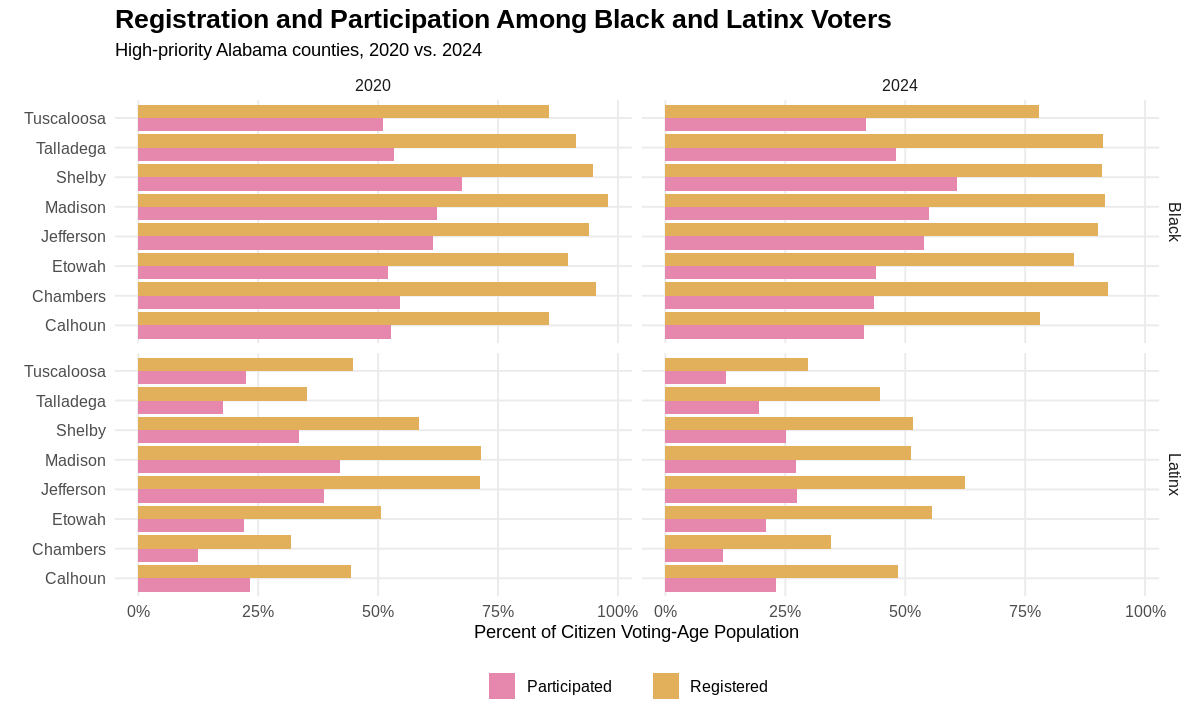

In [ ]:
registration_vs_participation %>%
  filter(
    county_name %in% priority_counties
  ) %>%
  ggplot(
    aes(
      x = county_name,
      y = rate,
      fill = stage
    )
  ) +
  geom_col(
    position = "dodge"
  ) +
  coord_flip() +
  facet_grid(
    race_group ~ year
  ) +
  scale_y_continuous(
    labels = label_percent(scale = 1)
  ) +
  scale_fill_manual(
    values = c(
      "Registered" = "#E2AF5A",
      "Participated" = "#E687AD"
    )
  ) +
  labs(
    title = "Registration and Participation Among Black and Latinx Voters",
    subtitle = "High-priority Alabama counties, 2020 vs. 2024",
    x = NULL,
    y = "Percent of Citizen Voting-Age Population",
    fill = NULL
  ) +
  project_theme

**Demographic Representation Gap**

In [ ]:
representation_analysis <- race %>%
  select(
    year,
    county_name,
    total_participants,
    total_black,
    total_hispanic
  ) %>%
  left_join(
    cvap %>%
      select(
        year,
        county_name,
        cvap_est_total,
        cvap_est_black,
        cvap_est_hispanic
      ),
    by = c("year", "county_name")
  ) %>%
  mutate(
    black_cvap_share =
      cvap_est_black / cvap_est_total * 100,

    black_voter_share =
      total_black / total_participants * 100,

    black_representation_gap =
      black_voter_share - black_cvap_share,

    hispanic_cvap_share =
      cvap_est_hispanic / cvap_est_total * 100,

    hispanic_voter_share =
      total_hispanic / total_participants * 100,

    hispanic_representation_gap =
      hispanic_voter_share - hispanic_cvap_share
  )

head(representation_analysis)

year,county_name,total_participants,total_black,total_hispanic,cvap_est_total,cvap_est_black,cvap_est_hispanic,black_cvap_share,black_voter_share,black_representation_gap,hispanic_cvap_share,hispanic_voter_share,hispanic_representation_gap
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2020,Autauga,27681,5091,189,41960,8135,840,19.387512,18.391677,-0.9958353,2.001907,0.6827788,-1.3191278
2024,Autauga,28401,5114,225,45205,9392,1199,20.776463,18.006408,-2.7700546,2.652361,0.7922256,-1.8601358
2020,Bibb,8797,1422,25,17585,4000,230,22.746659,16.164602,-6.5820575,1.307933,0.2841878,-1.0237451
2024,Bibb,9283,1239,35,17349,3668,199,21.142429,13.346978,-7.7954506,1.147040,0.3770333,-0.7700069
2020,Blount,27694,299,475,42980,610,2050,1.419265,1.079656,-0.3396085,4.769660,1.7151730,-3.0544873
2024,Blount,28255,321,572,43938,744,2218,1.693295,1.136082,-0.5572130,5.048022,2.0244205,-3.0236018


In [ ]:
representation_long <- representation_analysis %>%
  select(
    year,
    county_name,
    black_representation_gap,
    hispanic_representation_gap
  ) %>%
  pivot_longer(
    cols = c(
      black_representation_gap,
      hispanic_representation_gap
    ),
    names_to = "race_group",
    values_to = "representation_gap"
  ) %>%
  mutate(
    race_group = recode(
      race_group,
      "black_representation_gap" = "Black",
      "hispanic_representation_gap" = "Latinx"
    )
  )

head(representation_long)

year,county_name,race_group,representation_gap
<dbl>,<chr>,<chr>,<dbl>
2020,Autauga,Black,-0.9958353
2020,Autauga,Latinx,-1.3191278
2024,Autauga,Black,-2.7700546
2024,Autauga,Latinx,-1.8601358
2020,Bibb,Black,-6.5820575
2020,Bibb,Latinx,-1.0237451


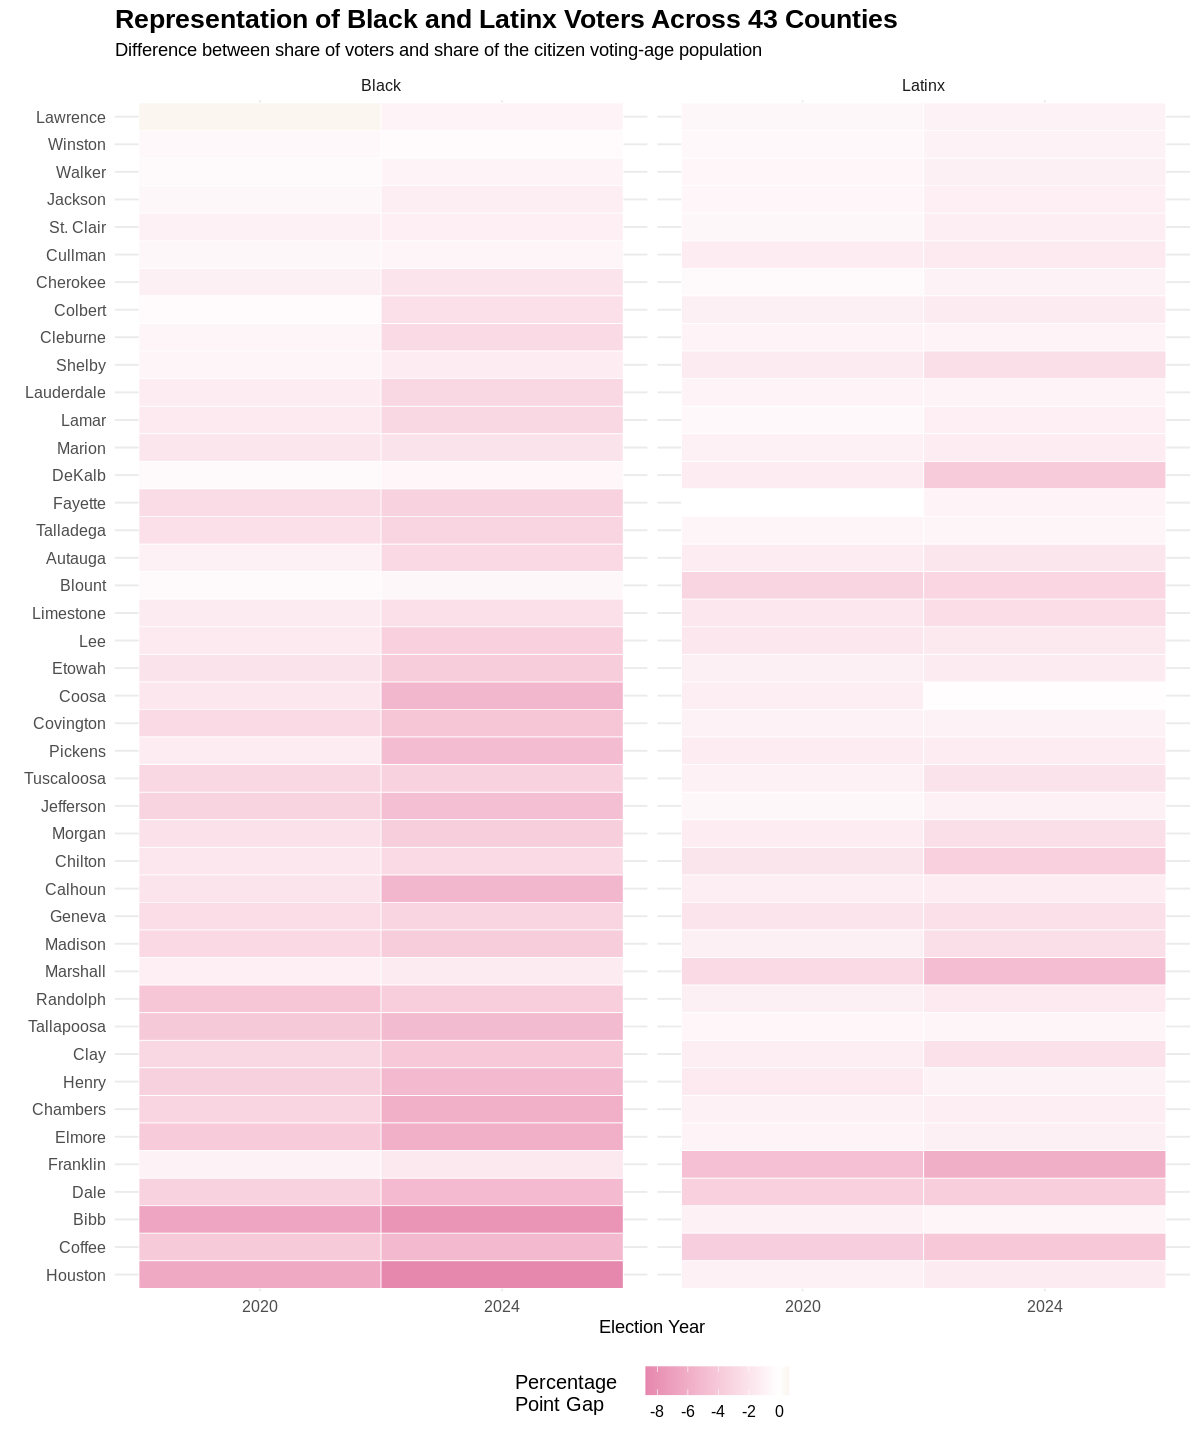

In [ ]:
options(
  repr.plot.width = 10,
  repr.plot.height = 12
)

representation_long %>%
  ggplot(
    aes(
      x = factor(year),
      y = reorder(
        county_name,
        representation_gap
      ),
      fill = representation_gap
    )
  ) +
  geom_tile(
    color = "white"
  ) +
  facet_wrap(
    ~ race_group,
    nrow = 1
  ) +
  scale_fill_gradient2(
    low = "#E687AD",
    mid = "#FFFFFF",
    high = "#B78B39",
    midpoint = 0
  ) +
  labs(
    title = "Representation of Black and Latinx Voters Across 43 Counties",
    subtitle = "Difference between share of voters and share of the citizen voting-age population",
    x = "Election Year",
    y = NULL,
    fill = "Percentage\nPoint Gap"
  ) +
  project_theme


**Did Turnout Decline Across All 43 Counties?**

In [ ]:
county_change_summary <- turnout_change %>%
  mutate(
    direction = case_when(
      change_2020_2024 < 0 ~ "Declined",
      change_2020_2024 > 0 ~ "Increased",
      TRUE ~ "No Change"
    ),

    county_group = if_else(
      county_name %in% priority_counties,
      "High-Priority",
      "Other Counties"
    )
  )

county_change_summary %>%
  count(direction)

direction,n
<chr>,<int>
Declined,36
Increased,7


**Priority vs. non-priority summary**

In [ ]:
county_change_summary %>%
  group_by(county_group) %>%
  summarise(
    counties = n(),

    counties_declining =
      sum(change_2020_2024 < 0, na.rm = TRUE),

    percent_declining =
      mean(change_2020_2024 < 0, na.rm = TRUE) * 100,

    average_change =
      mean(change_2020_2024, na.rm = TRUE),

    median_change =
      median(change_2020_2024, na.rm = TRUE)
  )

county_group,counties,counties_declining,percent_declining,average_change,median_change
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
High-Priority,8,8,100,-5.413360,-5.057523
Other Counties,35,28,80,-1.886563,-2.033256


**ALL 43**

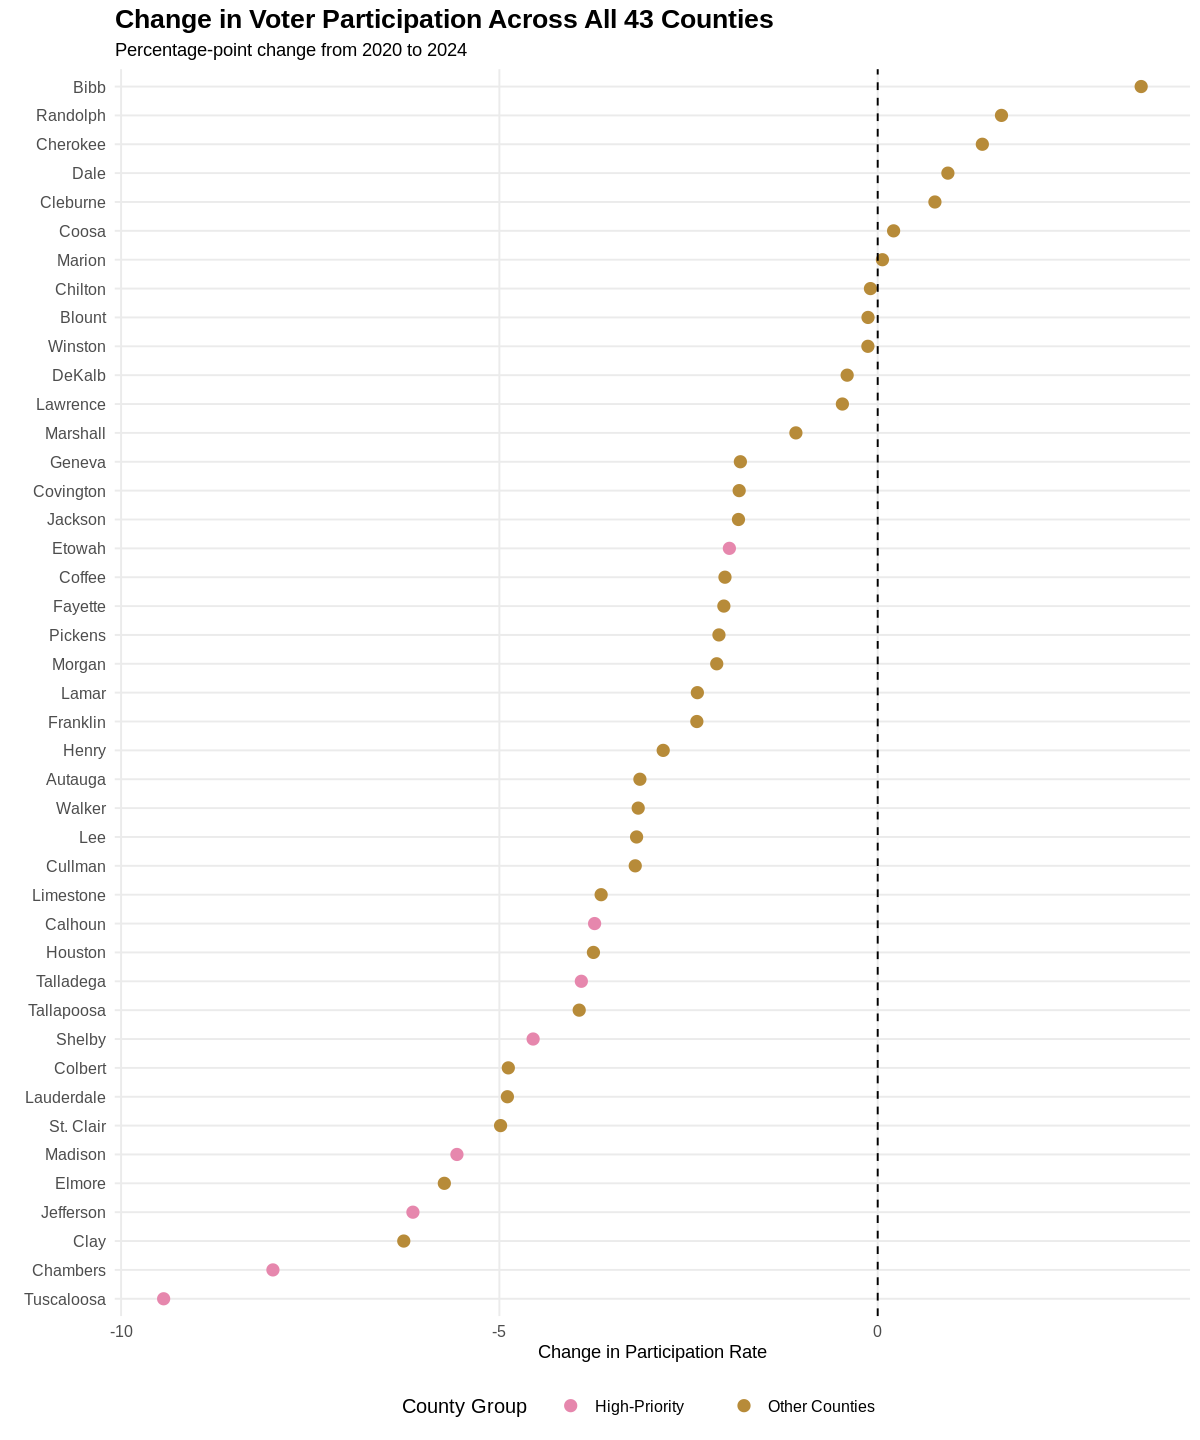

In [ ]:
county_change_summary %>%
  ggplot(
    aes(
      x = change_2020_2024,
      y = reorder(
        county_name,
        change_2020_2024
      ),
      color = county_group
    )
  ) +
  geom_point(
    size = 3
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  scale_color_manual(
    values = c(
      "High-Priority" = "#E687AD",
      "Other Counties" = "#B78B39"
    )
  ) +
  labs(
    title = "Change in Voter Participation Across All 43 Counties",
    subtitle = "Percentage-point change from 2020 to 2024",
    x = "Change in Participation Rate",
    y = NULL,
    color = "County Group"
  ) +
  project_theme

**Race with hughest turnout**

In [ ]:
overall_race_turnout <- race %>%
  select(
    year,
    county_name,
    total_asian,
    total_black,
    total_hispanic,
    total_white
  ) %>%
  left_join(
    cvap %>%
      select(
        year,
        county_name,
        cvap_est_asian,
        cvap_est_black,
        cvap_est_hispanic,
        cvap_est_white
      ),
    by = c("year", "county_name")
  ) %>%
  group_by(year) %>%
  summarise(
    Asian =
      sum(total_asian, na.rm = TRUE) /
      sum(cvap_est_asian, na.rm = TRUE) * 100,

    Black =
      sum(total_black, na.rm = TRUE) /
      sum(cvap_est_black, na.rm = TRUE) * 100,

    Latinx =
      sum(total_hispanic, na.rm = TRUE) /
      sum(cvap_est_hispanic, na.rm = TRUE) * 100,

    White =
      sum(total_white, na.rm = TRUE) /
      sum(cvap_est_white, na.rm = TRUE) * 100,

    .groups = "drop"
  ) %>%
  pivot_longer(
    cols = -year,
    names_to = "race_group",
    values_to = "participation_rate"
  )

overall_race_turnout

year,race_group,participation_rate
<dbl>,<chr>,<dbl>
2020,Asian,39.60627
2020,Black,57.29653
2020,Latinx,28.61892
2020,White,66.39758
2024,Asian,30.34574
2024,Black,49.55365
2024,Latinx,22.72544
2024,White,64.34433


In [ ]:
overall_race_turnout %>%
  group_by(year) %>%
  arrange(
    desc(participation_rate),
    .by_group = TRUE
  ) %>%
  mutate(
    rank = row_number()
  )

year,race_group,participation_rate,rank
<dbl>,<chr>,<dbl>,<int>
2020,White,66.39758,1
2020,Black,57.29653,2
2020,Asian,39.60627,3
2020,Latinx,28.61892,4
2024,White,64.34433,1
2024,Black,49.55365,2
2024,Asian,30.34574,3
2024,Latinx,22.72544,4


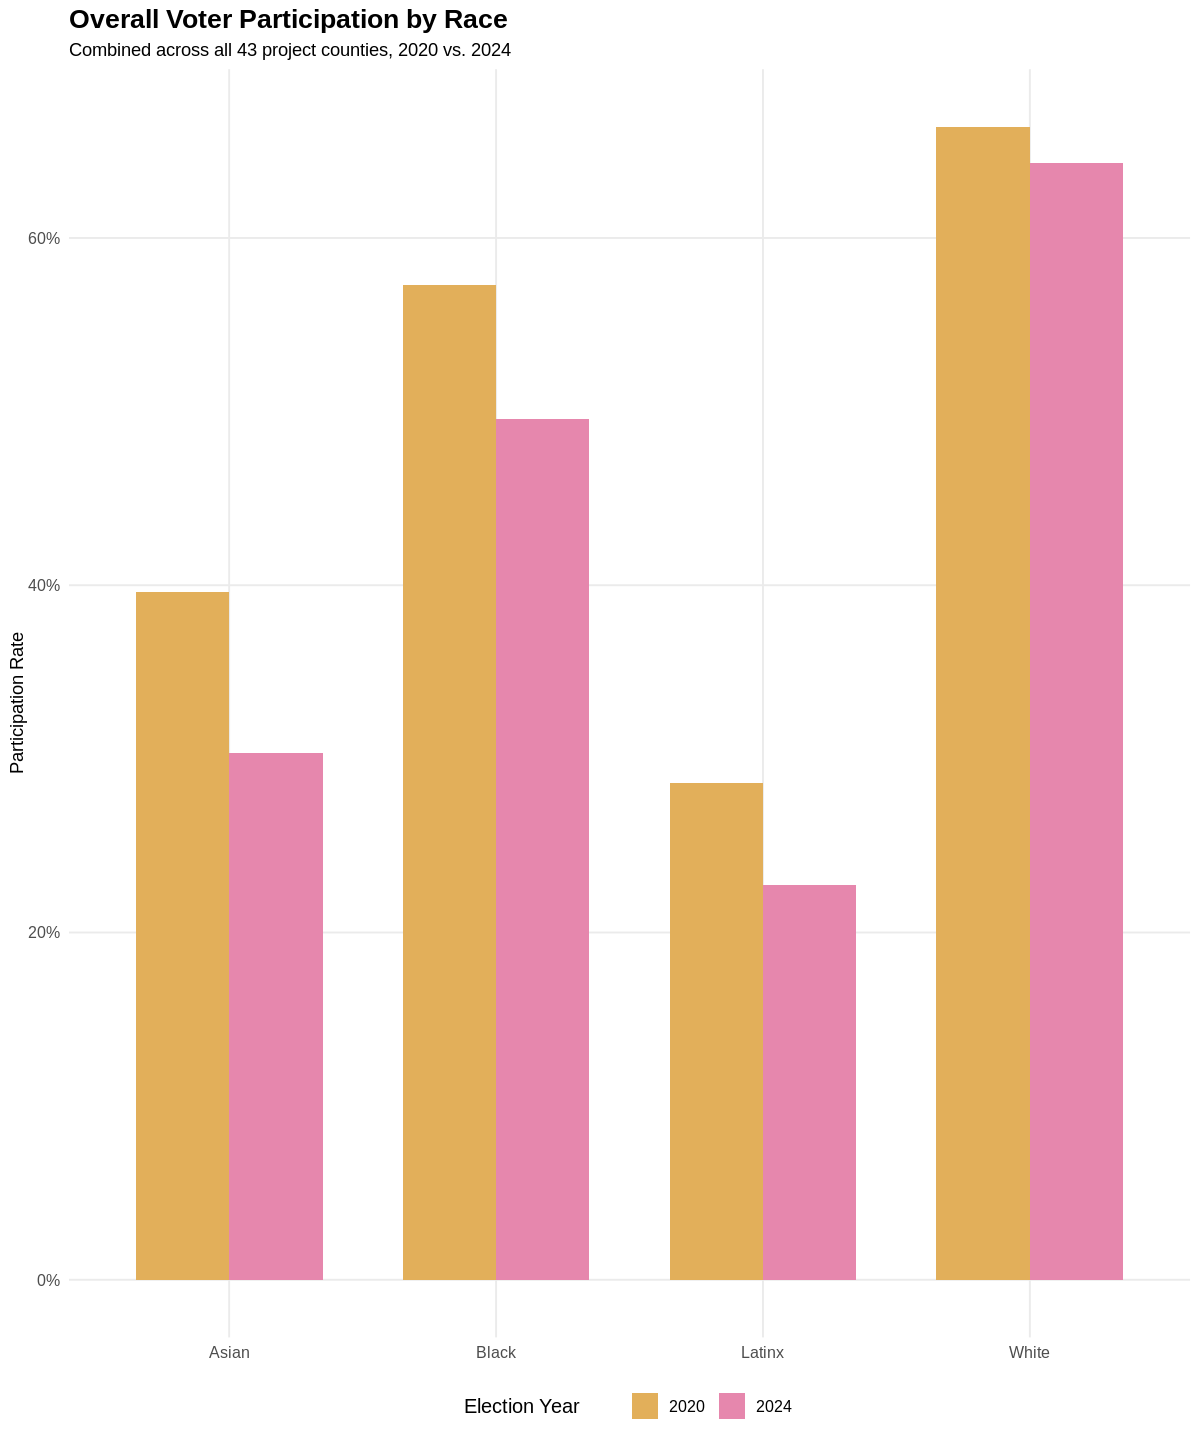

In [ ]:
overall_race_turnout %>%
  ggplot(
    aes(
      x = race_group,
      y = participation_rate,
      fill = factor(year)
    )
  ) +
  geom_col(
    position = "dodge",
    width = 0.7
  ) +
  scale_y_continuous(
    labels = label_percent(scale = 1)
  ) +
  scale_fill_manual(
    values = c(
      "2020" = "#E2AF5A",
      "2024" = "#E687AD"
    )
  ) +
  labs(
    title = "Overall Voter Participation by Race",
    subtitle = "Combined across all 43 project counties, 2020 vs. 2024",
    x = NULL,
    y = "Participation Rate",
    fill = "Election Year"
  ) +
  project_theme